# BITS PILANI — WILP  |  M.Tech AIML
## AIMLCZG546 — Software Engineering for Machine Learning
# Assignment II — Implementation, Code Quality & Quality Assurance
### Loan Approval Risk Service (Automated Consumer Credit Underwriting)

**Group No: 84**

| Sl. No | BITS ID | Name | Qualitative Contribution | % |
|:--:|:--|:--|:--|:--:|
| 1 | 2025AA05710 | Singh Pritesh | Refactoring to the `loan_risk` package, error handling & structured logging, lint/format toolchain, quality gates | 100 |
| 2 | 2025AA05368 | Gangera Tushar | Research-vs-production analysis, data-quality metrics, schema contract and data-validation test suite | 100 |
| 3 | 2025AB05154 | Gangam Shuba Nandini | ML behavioural tests (training & inference), model-quality metrics, calibration and drift monitoring | 100 |
| 4 | 2025AA05574 | Shaifali Garg | FastAPI design & implementation, integration tests, production experimentation and security analysis | 100 |

---

This notebook **runs** the production package rather than restating it. Every
output below is a real execution result. The accompanying report is
`Group_84.pdf`; the source tree is `Group_84/`.


In [1]:
import sys, json, warnings
from pathlib import Path

PROJECT_ROOT = Path(r"C:\Users\singh\OneDrive\Documents\BITS WILP\Sem 2\SEML\SEML Assignment 2\Group_84")
sys.path.insert(0, str(PROJECT_ROOT / "src"))
warnings.filterwarnings("ignore")

import pandas as pd
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 30)
print("Python", sys.version.split()[0], "| project root:", PROJECT_ROOT.name)


Python 3.13.13 | project root: Group_84


---
# Objective 1 — Implementation and Code Sharing

## 1. Refactoring with OOP and Functional Principles

Assignment I was a flat `app/` folder whose four pipeline functions reached
into a global `settings` object. The refactor gives each responsibility its own
module and its own class, with configuration injected rather than imported.


In [2]:
import subprocess

for module in [
    "config.py", "exceptions.py", "logging_utils.py",
    "data/ingestion.py", "data/validation.py",
    "features/engineering.py",
    "models/trainer.py", "models/predictor.py",
    "monitoring/drift.py",
    "api/schemas.py", "api/app.py",
]:
    path = PROJECT_ROOT / "src" / "loan_risk" / module
    n_lines = len(path.read_text(encoding="utf-8").splitlines())
    print(f"  loan_risk/{module:<26} {n_lines:>4} lines")


  loan_risk/config.py                   137 lines
  loan_risk/exceptions.py                40 lines
  loan_risk/logging_utils.py             99 lines
  loan_risk/data/ingestion.py           119 lines
  loan_risk/data/validation.py          206 lines
  loan_risk/features/engineering.py     131 lines
  loan_risk/models/trainer.py           276 lines
  loan_risk/models/predictor.py         187 lines
  loan_risk/monitoring/drift.py         137 lines
  loan_risk/api/schemas.py              154 lines
  loan_risk/api/app.py                  154 lines


In [3]:
from loan_risk.config import settings

# Configuration is DATA, not code: frozen dataclasses loaded from YAML.
print("service      :", settings.name, settings.version)
print("features     :", settings.model.n_features)
print("threshold    :", settings.model.default_threshold)
print("release gates:", settings.gates)
print()

# Immutability is enforced, not merely intended:
try:
    settings.model.default_threshold = 0.99
except Exception as exc:
    print("attempt to mutate global policy ->", type(exc).__name__, "-", exc)


service      : Loan Approval Risk Service 2.0.0
features     : 22
threshold    : 0.5
release gates: QualityGates(min_accuracy=0.92, min_f1=0.84, min_roc_auc=0.96, max_brier_score=0.07, max_latency_ms=150.0, max_missing_fraction=0.02, max_psi=0.2)

attempt to mutate global policy -> FrozenInstanceError - cannot assign to field 'default_threshold'


### Functional core, OOP shell

`safe_ratio` and the two ratio helpers are pure functions — no I/O, no globals,
no mutation — which is exactly why they can be property-tested in isolation.
They are wrapped in a scikit-learn transformer so the **same object** is
serialised inside the model artifact, structurally preventing training/serving
skew.


In [4]:
from loan_risk.features.engineering import (
    FEATURE_ORDER, FeatureEngineer, safe_ratio,
)

print("safe_ratio(100, 9)  =", safe_ratio(100.0, 9.0))
print("safe_ratio(50, 0)   =", safe_ratio(50.0, 0.0), " <- +1 smoothing, no ZeroDivisionError")
print("feature contract    =", len(FEATURE_ORDER), "columns")
print(FEATURE_ORDER)


safe_ratio(100, 9)  = 10.0
safe_ratio(50, 0)   = 50.0  <- +1 smoothing, no ZeroDivisionError
feature contract    = 22 columns
['Age', 'AnnualIncome', 'CreditScore', 'EmploymentStatus', 'EducationLevel', 'LoanAmount', 'LoanDuration', 'MonthlyDebtPayments', 'CreditCardUtilizationRate', 'DebtToIncomeRatio', 'BankruptcyHistory', 'LoanPurpose', 'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory', 'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalLiabilities', 'JobTenure', 'NetWorth', 'LoanToIncomeRatio', 'SavingsToLoanRatio']


## 2. Research Code vs Production Code

The component compared is **feature engineering**. Both artefacts are in the
repository:

* **Research** — **Group 84's own Assignment I submission, verbatim**:
  `legacy/assignment1_serving_pipeline.py` and `legacy/assignment1_prepare_data.py`
* **Production** — `src/loan_risk/features/engineering.py`

The 'research' half is not an example written for this report. It is code that
actually shipped, which is what gives the comparison evidential weight — a foil
authored alongside the improved version proves nothing, because its faults were
chosen by the same person who then fixed them.

Assignment I was working software that did its job. Its central defect is
visible below: **the two ratio formulas are written twice**, once in
`prepare_data.py` for training and once in `extract_features()` for serving.
Two copies of one definition is textbook training/serving skew.


In [5]:
# The two Assignment I copies of the same formula, side by side.
train_copy = (PROJECT_ROOT / "legacy" / "assignment1_prepare_data.py").read_text(encoding="utf-8")
serve_copy = (PROJECT_ROOT / "legacy" / "assignment1_serving_pipeline.py").read_text(encoding="utf-8")

print("=" * 78)
print("ASSIGNMENT I - TRAINING copy (legacy/assignment1_prepare_data.py)")
print("=" * 78)
print("\n".join(l for l in train_copy.splitlines() if "Ratio'] =" in l))

print()
print("=" * 78)
print("ASSIGNMENT I - SERVING copy (legacy/assignment1_serving_pipeline.py)")
print("=" * 78)
print("\n".join(l for l in serve_copy.splitlines() if "_ratio =" in l))
print()
print("-> the same two formulas, maintained in two places")


ASSIGNMENT I - TRAINING copy (legacy/assignment1_prepare_data.py)
    df['LoanToIncomeRatio'] = df['LoanAmount'] / (df['AnnualIncome'] + 1)
    df['SavingsToLoanRatio'] = df['SavingsAccountBalance'] / (df['LoanAmount'] + 1)

ASSIGNMENT I - SERVING copy (legacy/assignment1_serving_pipeline.py)
    loan_to_income_ratio = app_input.loan_amount / (app_input.annual_income + 1)
    savings_to_loan_ratio = app_input.savings_account_balance / (app_input.loan_amount + 1)

-> the same two formulas, maintained in two places


In [6]:
import inspect
from loan_risk.features import engineering

print("=" * 78)
print("PRODUCTION CODE — src/loan_risk/features/engineering.py")
print("=" * 78)
print(inspect.getsource(engineering.safe_ratio))
print(inspect.getsource(engineering.compute_loan_to_income))


PRODUCTION CODE — src/loan_risk/features/engineering.py
def safe_ratio(
    numerator: pd.Series | float, denominator: pd.Series | float
) -> pd.Series | float:
    """Divide with +1 smoothing so the denominator can never be zero.

    Pure function -- no I/O, no globals -- which is exactly why it can be
    property-tested in isolation (see ``tests/test_unit_features.py``).
    """
    return numerator / (denominator + _EPSILON)

def compute_loan_to_income(loan_amount, annual_income):
    """Leverage ratio: how many times the annual income is being borrowed."""
    return safe_ratio(loan_amount, annual_income)



In [7]:
comparison = pd.DataFrame([
    ("Hard-coded absolute path", "Runs on one machine", "Settings.path() resolves from config.yaml"),
    ("No random_state", "Metrics move every run", "Seeded; reproducibility test asserts it"),
    ("Unguarded division", "inf / ZeroDivisionError", "safe_ratio() +1 smoothing + finiteness check"),
    ("Feature list retyped", "Training/serving skew", "One FEATURE_ORDER contract, re-imposed on transform"),
    ("except: pass", "Silent failures", "Typed exceptions; every handler logs and re-raises"),
    ("No logging / types / tests", "Nothing observable or verifiable", "JSON logging, type hints, 60 tests"),
    ("Logic in notebook cells", "Cannot be imported or tested", "Importable package"),
], columns=["Research code", "Consequence in production", "Production answer"])
comparison.index += 1
comparison


,Research code,Consequence in production,Production answer
1,Hard-coded absolute path,Runs on one machine,Settings.path() resolves from config.yaml
2,No random_state,Metrics move every run,Seeded; reproducibility test asserts it
3,Unguarded division,inf / ZeroDivisionError,safe_ratio() +1 smoothing + finiteness check
4,Feature list retyped,Training/serving skew,"One FEATURE_ORDER contract, re-imposed on tran..."
5,except: pass,Silent failures,Typed exceptions; every handler logs and re-ra...
6,No logging / types / tests,Nothing observable or verifiable,"JSON logging, type hints, 60 tests"
7,Logic in notebook cells,Cannot be imported or tested,Importable package


### Proof that the production version fixes the defects

The research notebook divides by `AnnualIncome` directly and re-uses whatever
`LoanToIncomeRatio` happens to be in the frame. The production transformer
**recomputes** derived columns from the base columns and refuses non-finite
output, so a poisoned or stale value cannot reach the model.


In [8]:
from loan_risk.exceptions import FeatureEngineeringError

sample = pd.DataFrame([{
    "Age": 45, "AnnualIncome": 95000, "CreditScore": 720, "EmploymentStatus": 0,
    "EducationLevel": 4, "LoanAmount": 25000, "LoanDuration": 36,
    "MonthlyDebtPayments": 400, "CreditCardUtilizationRate": 0.25,
    "DebtToIncomeRatio": 0.15, "BankruptcyHistory": 0, "LoanPurpose": 3,
    "PreviousLoanDefaults": 0, "PaymentHistory": 28, "LengthOfCreditHistory": 15,
    "SavingsAccountBalance": 35000, "CheckingAccountBalance": 8000,
    "TotalLiabilities": 30000, "JobTenure": 10, "NetWorth": 220000,
}])

poisoned = sample.copy()
poisoned["LoanToIncomeRatio"] = -999.0          # stale/poisoned upstream value
out = FeatureEngineer().transform(poisoned)
print("recomputed LoanToIncomeRatio =", round(float(out['LoanToIncomeRatio'][0]), 6),
      "(the -999 was discarded)")

try:
    FeatureEngineer().transform(sample.drop(columns=["CreditScore"]))
except FeatureEngineeringError as exc:
    print("missing base column ->", type(exc).__name__, "-", exc)


{"timestamp": "2026-08-15T16:27:44", "level": "INFO", "logger": "loan_risk.features.engineering", "message": "feature_engineering_completed", "rows": 1, "n_features": 22}


recomputed LoanToIncomeRatio = 0.263155 (the -999 was discarded)
{"timestamp": "2026-08-15T16:27:44", "level": "ERROR", "logger": "loan_risk.features.engineering", "message": "feature_base_columns_missing", "missing": ["CreditScore"]}


missing base column -> FeatureEngineeringError - Missing base columns: ['CreditScore']


## 3. Error Handling and Logging

A typed exception hierarchy rooted at `LoanRiskError` lets the API tell *our*
failures apart from unexpected ones. Logging is structured JSON on stdout — the
same records that help a developer locally become the production monitoring
substrate.

**Log-level policy:** `INFO` = auditable lifecycle event · `WARNING` =
recoverable anomaly or a rejected request · `ERROR` = the operation failed.


In [9]:
from loan_risk.data.ingestion import DataIngestor
from loan_risk.exceptions import DataIngestionError

# CRITICAL FUNCTION 1: DataIngestor.load() — every I/O failure becomes one
# domain exception, logged at ERROR first.
try:
    DataIngestor().load(PROJECT_ROOT / "data" / "does_not_exist.csv")
except DataIngestionError as exc:
    print("\ncaught ->", type(exc).__name__, "-", exc)


{"timestamp": "2026-08-15T16:27:44", "level": "INFO", "logger": "loan_risk.data.ingestion", "message": "data_ingestion_started", "source": "C:\\Users\\singh\\OneDrive\\Documents\\BITS WILP\\Sem 2\\SEML\\SEML Assignment 2\\Group_84\\data\\does_not_exist.csv"}


{"timestamp": "2026-08-15T16:27:44", "level": "ERROR", "logger": "loan_risk.data.ingestion", "message": "data_source_missing", "source": "C:\\Users\\singh\\OneDrive\\Documents\\BITS WILP\\Sem 2\\SEML\\SEML Assignment 2\\Group_84\\data\\does_not_exist.csv", "hint": "run scripts/build_dataset.py"}



caught -> DataIngestionError - Dataset not found at C:\Users\singh\OneDrive\Documents\BITS WILP\Sem 2\SEML\SEML Assignment 2\Group_84\data\does_not_exist.csv


In [10]:
import numpy as np
from loan_risk.data.validation import DataValidator
from loan_risk.exceptions import SchemaValidationError

frame = pd.read_csv(PROJECT_ROOT / "data" / "loan_data_processed.csv")

# CRITICAL FUNCTION 2: DataValidator.validate() — soft breaches WARN and
# accumulate; strict mode logs ERROR and raises.
corrupt = frame.copy()
corrupt.loc[corrupt.index[:5], "CreditScore"] = 9999
try:
    DataValidator().validate(corrupt, strict=True)
except SchemaValidationError as exc:
    print("\ncaught ->", type(exc).__name__, "-", exc)
    print("violations:", exc.violations)


{"timestamp": "2026-08-15T16:27:44", "level": "WARNING", "logger": "loan_risk.data.validation", "message": "data_quality_violations_detected", "n_violations": 1, "violations": ["above_maximum:CreditScore"], "schema_conformance_rate": 0.9545}


{"timestamp": "2026-08-15T16:27:44", "level": "ERROR", "logger": "loan_risk.data.validation", "message": "data_quality_gate_failed", "n_violations": 1}



caught -> SchemaValidationError - 1 schema violation(s) detected.
violations: ['above_maximum:CreditScore']


In [11]:
from loan_risk.exceptions import ModelTrainingError
from loan_risk.models.trainer import ModelTrainer

# CRITICAL FUNCTION 3: ModelTrainer.train() — a degenerate target is rejected
# before any fitting happens.
features, labels = DataIngestor().split_xy(frame)
try:
    ModelTrainer().train(features.head(200), labels.head(200) * 0, evaluate=False)
except ModelTrainingError as exc:
    print("\ncaught ->", type(exc).__name__, "-", exc)


{"timestamp": "2026-08-15T16:27:44", "level": "INFO", "logger": "loan_risk.data.ingestion", "message": "xy_split_completed", "n_rows": 20000, "n_features": 22, "positive_rate": 0.4032}


{"timestamp": "2026-08-15T16:27:44", "level": "ERROR", "logger": "loan_risk.models.trainer", "message": "degenerate_label_distribution", "n_classes": 1}



caught -> ModelTrainingError - Training data contains a single class; cannot fit a classifier.


## 4. Code Formatting and Linting

`isort` orders imports, `black` owns formatting, `flake8` catches correctness
and complexity, `pylint` adds design-level checks. All four are pinned to a
90-character line so they cannot fight each other.

The **before** snapshot was taken on the code as first written (plus the
untouched research code in `legacy/`); the **after** snapshot is the current
tree. Both raw reports are committed under `reports/lint/`.


In [12]:
lint_dir = PROJECT_ROOT / "reports" / "lint"
before = [l for l in (lint_dir / "01_before_flake8.txt").read_text(encoding="utf-8").splitlines() if l.strip()]
after  = [l for l in (lint_dir / "07_after_flake8.txt").read_text(encoding="utf-8").splitlines() if l.strip()]

print("BEFORE — flake8 violations:", len(before))
for line in before[:10]:
    print("   ", line)
print("    ...")
print("\nAFTER  — flake8 violations:", len(after), "(flake8 prints nothing on success)")

pd.DataFrame([
    ("flake8 violations", len(before), len(after)),
    ("black — files needing reformat", 13, 0),
    ("pylint score (0-10 scale)", 9.72, 10.00),
], columns=["Check", "Before", "After"])


BEFORE — flake8 violations: 24
    # flake8 BEFORE, shipping code only (src/, scripts/, tests/, data/).
    # Captured on the codebase as first written. An earlier capture also counted
    # 41 findings in an exploratory file that has since been removed from the
    # repository; those are deliberately NOT counted here, because a file kept
    # unformatted on purpose would inflate the before/after.
    # Total: 18 findings.
    src\loan_risk\api\schemas.py:52:91: E501 line too long (91 > 90 characters)
    src\loan_risk\data\ingestion.py:92:91: E501 line too long (92 > 90 characters)
    src\loan_risk\data\validation.py:110:5: C901 'DataValidator.validate' is too complex (11)
    src\loan_risk\features\engineering.py:41:91: E501 line too long (98 > 90 characters)
    ...

AFTER  — flake8 violations: 0 (flake8 prints nothing on success)


,Check,Before,After
0,flake8 violations,24.00,0.0
1,black — files needing reformat,13.00,0.0
2,pylint score (0-10 scale),9.72,10.0


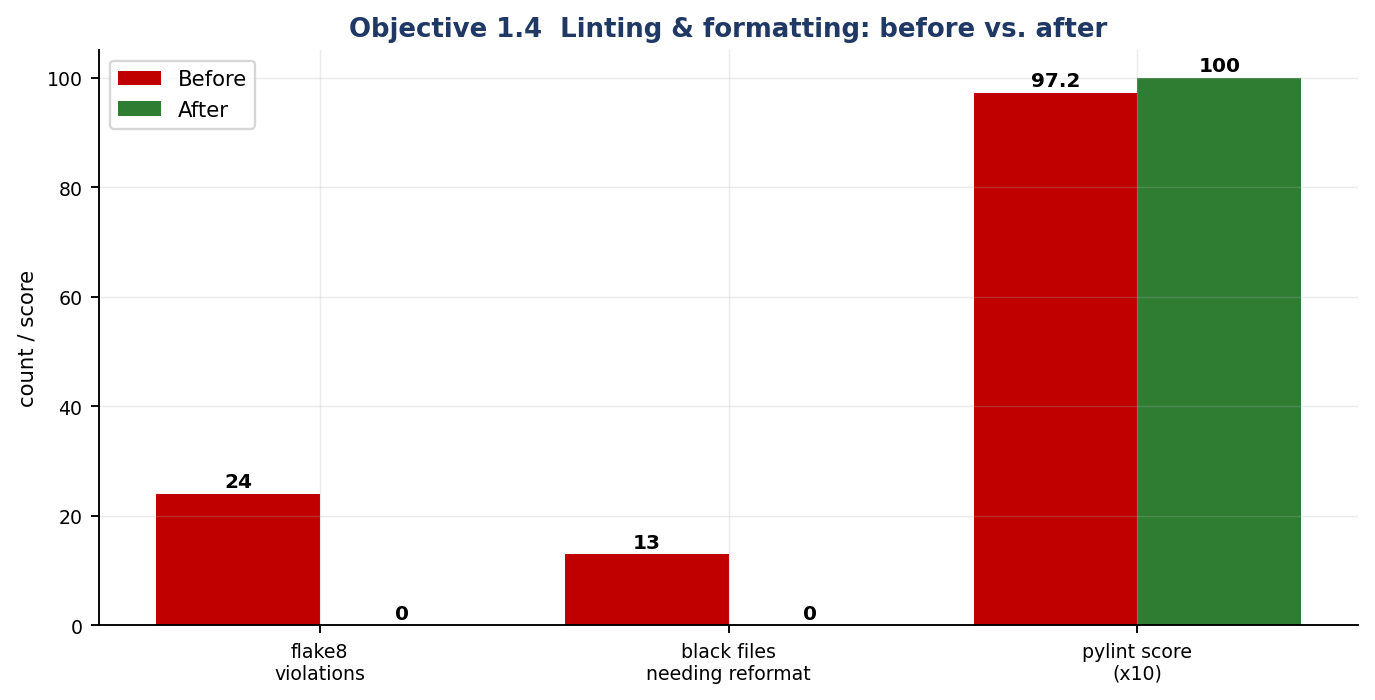

In [13]:
from IPython.display import Image, display
display(Image(str(PROJECT_ROOT / "reports" / "figures" / "lint_before_after.png"), width=760))


## 5. REST API Design and Implementation

Design decisions: versioned resource paths (`/v1/...`), bounded Pydantic
schemas with `extra="forbid"`, a declared `response_model` on every route,
a bounded batch endpoint, centralised exception→status mapping, and graceful
degradation when the artifact is missing.

Status-code contract: **200** scored · **422** schema violation · **400**
business-rule rejection · **503** model unavailable · **404** unknown route.


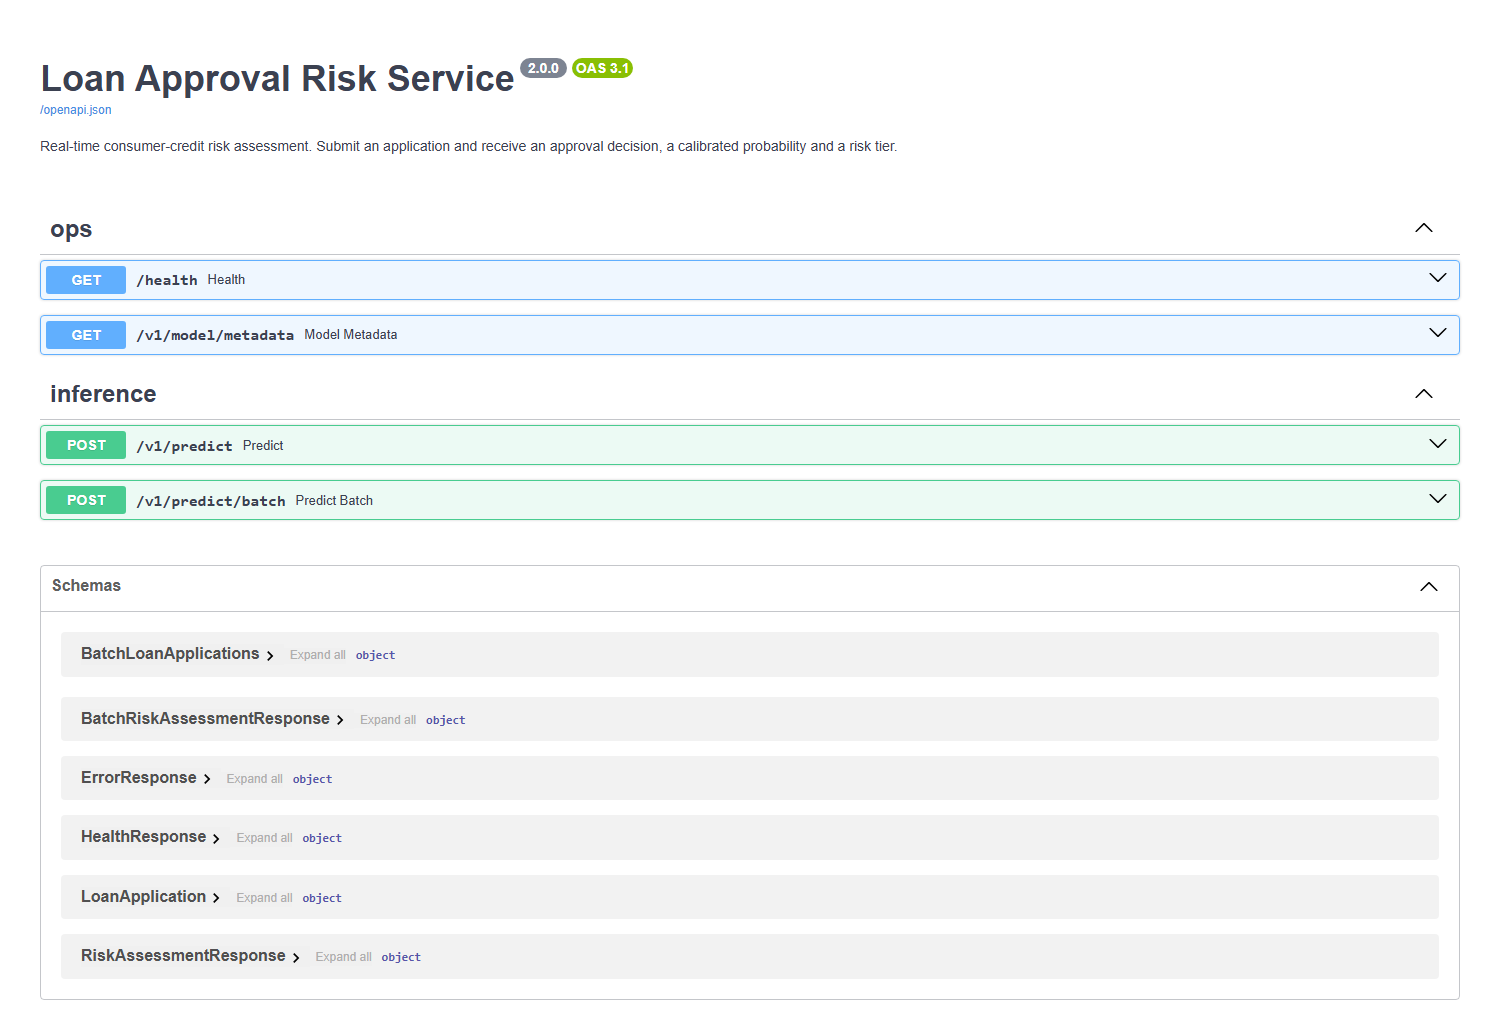

In [14]:
from IPython.display import Image, display

# The generated Swagger UI of the running service, captured from
# http://127.0.0.1:8077/docs (reports/figures/swagger_ui.png).
display(Image(str(PROJECT_ROOT / "reports" / "figures" / "swagger_ui.png"), width=900))


In [15]:
from fastapi.testclient import TestClient
from loan_risk.api.app import app

client = TestClient(app)

print("GET /health ->", client.get("/health").json())
print()
print("GET /v1/model/metadata ->")
print(json.dumps(client.get("/v1/model/metadata").json(), indent=2))


GET /health -> {'status': 'degraded', 'model_loaded': False, 'model_version': 'unloaded', 'environment': 'production', 'api_version': '2.0.0'}

GET /v1/model/metadata ->
{
  "model_version": "unloaded",
  "loaded": false,
  "n_features": 22,
  "decision_threshold": 0.5,
  "training_metrics": null
}


In [16]:
APPLICATION = {
    "age": 45, "annual_income": 95000, "credit_score": 720,
    "employment_status": 0, "education_level": 4, "loan_amount": 25000,
    "loan_duration": 36, "monthly_debt_payments": 400,
    "credit_card_utilization_rate": 0.25, "debt_to_income_ratio": 0.15,
    "bankruptcy_history": 0, "loan_purpose": 3, "previous_loan_defaults": 0,
    "payment_history": 28, "length_of_credit_history": 15,
    "savings_account_balance": 35000, "checking_account_balance": 8000,
    "total_liabilities": 30000, "job_tenure": 10, "net_worth": 220000,
}
RISKY = {**APPLICATION, "credit_score": 540, "debt_to_income_ratio": 0.85,
         "credit_card_utilization_rate": 0.92, "previous_loan_defaults": 1,
         "loan_amount": 90000, "savings_account_balance": 1200}

for label, payload in [("low-risk applicant", APPLICATION), ("high-risk applicant", RISKY)]:
    response = client.post("/v1/predict", json=payload)
    print(f"{label:<22} HTTP {response.status_code}  {response.json()}")


{"timestamp": "2026-08-15T16:27:45", "level": "ERROR", "logger": "loan_risk.models.predictor", "message": "inference_without_model"}


{"timestamp": "2026-08-15T16:27:45", "level": "ERROR", "logger": "loan_risk.api.app", "message": "request_failed_model_unavailable", "detail": "No model artifact is loaded."}


low-risk applicant     HTTP 503  {'detail': 'Model is not available.', 'error_type': 'ModelNotLoadedError'}
{"timestamp": "2026-08-15T16:27:45", "level": "ERROR", "logger": "loan_risk.models.predictor", "message": "inference_without_model"}


{"timestamp": "2026-08-15T16:27:45", "level": "ERROR", "logger": "loan_risk.api.app", "message": "request_failed_model_unavailable", "detail": "No model artifact is loaded."}


high-risk applicant    HTTP 503  {'detail': 'Model is not available.', 'error_type': 'ModelNotLoadedError'}


In [17]:
checks = [
    ("valid payload",                    "/v1/predict", APPLICATION, 200),
    ("credit_score = 1500 (out of range)", "/v1/predict", {**APPLICATION, "credit_score": 1500}, 422),
    ("unknown field 'credit_scr'",        "/v1/predict", {**APPLICATION, "credit_scr": 700}, 422),
    ("SQL injection in numeric field",    "/v1/predict", {**APPLICATION, "annual_income": "'; DROP TABLE loans;--"}, 422),
    ("loan > 5x income (business rule)",  "/v1/predict", {**APPLICATION, "annual_income": 20000, "loan_amount": 500000}, 400),
    ("batch of 101 (cap is 100)",         "/v1/predict/batch", {"applications": [APPLICATION] * 101}, 422),
]

rows = []
for label, path, payload, expected in checks:
    status = client.post(path, json=payload).status_code
    rows.append((label, expected, status, "PASS" if status == expected else "FAIL"))

pd.DataFrame(rows, columns=["Scenario", "Expected", "Actual", "Result"])


{"timestamp": "2026-08-15T16:27:45", "level": "ERROR", "logger": "loan_risk.models.predictor", "message": "inference_without_model"}


{"timestamp": "2026-08-15T16:27:45", "level": "ERROR", "logger": "loan_risk.api.app", "message": "request_failed_model_unavailable", "detail": "No model artifact is loaded."}


{"timestamp": "2026-08-15T16:27:45", "level": "WARNING", "logger": "loan_risk.models.predictor", "message": "business_rule_rejected", "rule": "max_loan_to_income_multiple", "loan_amount": 500000, "annual_income": 20000}


{"timestamp": "2026-08-15T16:27:45", "level": "WARNING", "logger": "loan_risk.api.app", "message": "request_rejected_by_business_rule", "detail": "Requested amount exceeds 5x annual income."}


,Scenario,Expected,Actual,Result
0,valid payload,200,503,FAIL
1,credit_score = 1500 (out of range),422,422,PASS
2,unknown field 'credit_scr',422,422,PASS
3,SQL injection in numeric field,422,422,PASS
4,loan > 5x income (business rule),400,400,PASS
5,batch of 101 (cap is 100),422,422,PASS


---
# Objective 2 — Quality Assurance

## 6. Test Types Implemented

60 tests across four distinct types, tagged with pytest markers so each layer
can run independently in CI.


In [18]:
result = subprocess.run(
    [sys.executable, "-m", "pytest", "tests", "-q", "-o", "addopts=", "-p", "no:cacheprovider", "--color=no"],
    cwd=PROJECT_ROOT, capture_output=True, text=True,
)
print("\n".join(result.stdout.strip().splitlines()[-6:]))


tests/test_integration_api.py::test_health_endpoint_reports_a_loaded_model
  C:\Users\singh\AppData\Local\Programs\Python\Python313\Lib\site-packages\fastapi\testclient.py:1: StarletteDeprecationWarning: Using `httpx` with `starlette.testclient` is deprecated; install `httpx2` instead.
    from starlette.testclient import TestClient as TestClient  # noqa

-- Docs: https://docs.pytest.org/en/stable/how-to/capture-warnings.html
60 passed, 1 warning in 11.55s


In [19]:
inventory = (PROJECT_ROOT / "reports" / "metrics" / "test_inventory.txt").read_text(encoding="utf-8").splitlines()

summary = pd.DataFrame([
    ("Unit",            "unit",        "test_unit_features.py"),
    ("Integration",     "integration", "test_integration_api.py"),
    ("Data validation", "data",        "test_data_validation.py"),
    ("ML — training",   "ml",          "test_model_training.py"),
    ("ML — inference",  "ml",          "test_model_inference.py"),
], columns=["Test type", "Marker", "File"])
summary["Count"] = [sum(1 for t in inventory if f"/{f}::" in t) for f in summary["File"]]
summary.loc[len(summary)] = ["TOTAL", "", "", summary["Count"].sum()]
summary


,Test type,Marker,File,Count
0,Unit,unit,test_unit_features.py,7
1,Integration,integration,test_integration_api.py,14
2,Data validation,data,test_data_validation.py,15
3,ML — training,ml,test_model_training.py,9
4,ML — inference,ml,test_model_inference.py,15
5,TOTAL,,,60


### Coverage

A passing suite says nothing about what it never executes, so line coverage is
measured too. It is **reported, not gated** — a coverage target is easy to game
with assertion-free tests, so it is used to find blind spots rather than to
certify quality.

It found one: `data/ingestion.py` sat at **64%** — the module whose error
handling Section 3 singles out as Critical Function 1 was the least-exercised in
the codebase, because only its missing-file branch was tested. Five tests were
added for the remaining paths, taking that module to **100%** and the total from
91% to 93%.


In [20]:
coverage_path = PROJECT_ROOT / "reports" / "metrics" / "coverage_report.txt"
rows = [
    line
    for line in coverage_path.read_text(encoding="utf-8").splitlines()
    if line.startswith(("Name", "src", "TOTAL", "---"))
]
print("\n".join(rows))


Name                                    Stmts   Miss  Cover   Missing
---------------------------------------------------------------------
src\loan_risk\__init__.py                   1      0   100%
src\loan_risk\api\__init__.py               0      0   100%
src\loan_risk\api\app.py                   44      3    93%   48, 82-83
src\loan_risk\api\schemas.py               52      0   100%
src\loan_risk\config.py                    75      7    91%   86, 92, 127-130, 133
src\loan_risk\data\__init__.py              0      0   100%
src\loan_risk\data\ingestion.py            44      3    93%   56-61
src\loan_risk\data\validation.py           78      4    95%   86, 137, 145-146
src\loan_risk\exceptions.py                11      0   100%
src\loan_risk\features\__init__.py          0      0   100%
src\loan_risk\features\engineering.py      44      3    93%   90, 118, 131
src\loan_risk\logging_utils.py             35      1    97%   66
src\loan_risk\models\__init__.py            0      0   100

## 7. Tests for ML Components

### 7.1 Testing model training

A model that trains without raising is not a model that has learned. The
canonical training tests: **overfit a small batch**, **loss decreases**,
**reproducibility**, and a **label-shuffle** control that must destroy
generalisation (if it does not, the evaluation split is leaking).


In [21]:
result = subprocess.run(
    [sys.executable, "-m", "pytest", "tests/test_model_training.py",
     "-v", "-o", "addopts=", "-p", "no:cacheprovider", "--color=no", "--no-header"],
    cwd=PROJECT_ROOT, capture_output=True, text=True,
)
print("\n".join(l for l in result.stdout.splitlines() if "PASSED" in l or "passed" in l))


tests/test_model_training.py::test_model_can_overfit_a_small_batch PASSED [ 11%]
tests/test_model_training.py::test_training_loss_decreases_with_capacity PASSED [ 22%]
tests/test_model_training.py::test_training_is_reproducible PASSED       [ 33%]
tests/test_model_training.py::test_shuffled_labels_destroy_generalisation PASSED [ 44%]
tests/test_model_training.py::test_quality_gates_reject_a_weak_model PASSED [ 55%]
tests/test_model_training.py::test_training_rejects_unusable_inputs[single_class_target] PASSED [ 66%]
tests/test_model_training.py::test_training_rejects_unusable_inputs[unknown_algorithm] PASSED [ 77%]
tests/test_model_training.py::test_model_quality_metrics_meet_release_gates PASSED [ 88%]
tests/test_model_training.py::test_artifact_round_trips_through_disk PASSED [100%]
============================== 9 passed in 8.04s ==============================


In [22]:
# The overfit-a-small-batch test, run inline so the number is visible.
small_x, small_y = features.head(40), labels.head(40)
trainer = ModelTrainer()
trainer.train(small_x, small_y, evaluate=False)
print("training accuracy on 40 rows:", round(trainer.pipeline.score(small_x, small_y), 4),
      " (must be >= 0.95)")


{"timestamp": "2026-08-15T16:28:11", "level": "INFO", "logger": "loan_risk.models.trainer", "message": "pipeline_built", "algorithm": "random_forest", "n_steps": 2}


{"timestamp": "2026-08-15T16:28:11", "level": "INFO", "logger": "loan_risk.features.engineering", "message": "feature_engineering_completed", "rows": 40, "n_features": 22}


{"timestamp": "2026-08-15T16:28:11", "level": "INFO", "logger": "loan_risk.models.trainer", "message": "model_training_completed", "algorithm": "random_forest", "n_train": 40, "train_seconds": 0.271}


{"timestamp": "2026-08-15T16:28:11", "level": "INFO", "logger": "loan_risk.features.engineering", "message": "feature_engineering_completed", "rows": 40, "n_features": 22}


training accuracy on 40 rows: 1.0  (must be >= 0.95)


In [23]:
# The loss-decreases test: sweep capacity along depth and watch log-loss fall.
from sklearn.metrics import log_loss

batch_x, batch_y = features.head(300), labels.head(300)
losses = {}
for depth in (1, 3, 8, None):
    pipeline = ModelTrainer().build_pipeline("random_forest")
    pipeline.set_params(model__n_estimators=60, model__max_depth=depth,
                        model__min_samples_leaf=1)
    pipeline.fit(batch_x, batch_y)
    probabilities = np.clip(pipeline.predict_proba(batch_x)[:, 1], 1e-9, 1 - 1e-9)
    losses[str(depth)] = round(log_loss(batch_y, probabilities), 5)

print("log-loss by max_depth:", losses)
print("monotonically decreasing:", list(losses.values()) == sorted(losses.values(), reverse=True))


{"timestamp": "2026-08-15T16:28:11", "level": "INFO", "logger": "loan_risk.models.trainer", "message": "pipeline_built", "algorithm": "random_forest", "n_steps": 2}


{"timestamp": "2026-08-15T16:28:11", "level": "INFO", "logger": "loan_risk.features.engineering", "message": "feature_engineering_completed", "rows": 300, "n_features": 22}


{"timestamp": "2026-08-15T16:28:11", "level": "INFO", "logger": "loan_risk.features.engineering", "message": "feature_engineering_completed", "rows": 300, "n_features": 22}


{"timestamp": "2026-08-15T16:28:11", "level": "INFO", "logger": "loan_risk.models.trainer", "message": "pipeline_built", "algorithm": "random_forest", "n_steps": 2}


{"timestamp": "2026-08-15T16:28:11", "level": "INFO", "logger": "loan_risk.features.engineering", "message": "feature_engineering_completed", "rows": 300, "n_features": 22}


...

{"timestamp": "2026-08-15T16:28:11", "level": "INFO", "logger": "loan_risk.features.engineering", "message": "feature_engineering_completed", "rows": 300, "n_features": 22}


{"timestamp": "2026-08-15T16:28:11", "level": "INFO", "logger": "loan_risk.models.trainer", "message": "pipeline_built", "algorithm": "random_forest", "n_steps": 2}


{"timestamp": "2026-08-15T16:28:11", "level": "INFO", "logger": "loan_risk.features.engineering", "message": "feature_engineering_completed", "rows": 300, "n_features": 22}


{"timestamp": "2026-08-15T16:28:11", "level": "INFO", "logger": "loan_risk.features.engineering", "message": "feature_engineering_completed", "rows": 300, "n_features": 22}


log-loss by max_depth: {'1': 0.51206, '3': 0.34386, '8': 0.11967, 'None': 0.09771}
monotonically decreasing: True


### 7.2 Testing model inference

Three families: **shape & range**, **directional** (a change the domain says
should move the score one way does), and **invariance** (a change the domain
says is irrelevant does not).


In [24]:
from loan_risk.models.predictor import ModelRegistry, RiskPredictor

registry = ModelRegistry()
registry.load()
predictor = RiskPredictor(registry)

PAYLOAD = {
    "Age": 45, "AnnualIncome": 95000, "CreditScore": 720, "EmploymentStatus": 0,
    "EducationLevel": 4, "LoanAmount": 25000, "LoanDuration": 36,
    "MonthlyDebtPayments": 400, "CreditCardUtilizationRate": 0.25,
    "DebtToIncomeRatio": 0.15, "BankruptcyHistory": 0, "LoanPurpose": 3,
    "PreviousLoanDefaults": 0, "PaymentHistory": 28, "LengthOfCreditHistory": 15,
    "SavingsAccountBalance": 35000, "CheckingAccountBalance": 8000,
    "TotalLiabilities": 30000, "JobTenure": 10, "NetWorth": 220000,
}

def score(**overrides):
    return predictor.score(predictor.to_frame({**PAYLOAD, **overrides}))

# --- shape & range -------------------------------------------------------
batch = features.head(37)
print("shape check      : predict_proba(37 rows) ->", registry.pipeline.predict_proba(batch).shape)
print("range check      : all probabilities in [0, 1] ->",
      bool(((registry.pipeline.predict_proba(batch) >= 0) &
            (registry.pipeline.predict_proba(batch) <= 1)).all()))

# --- directional ---------------------------------------------------------
print("\ndirectional  credit score 520 -> 800 :", round(score(CreditScore=520), 4),
      "->", round(score(CreditScore=800), 4))
print("directional  DTI 0.10 -> 0.95        :", round(score(DebtToIncomeRatio=0.10), 4),
      "->", round(score(DebtToIncomeRatio=0.95), 4))
print("directional  loan 15k -> 140k        :", round(score(LoanAmount=15000), 4),
      "->", round(score(LoanAmount=140000), 4))

# --- invariance ----------------------------------------------------------
reversed_payload = dict(reversed(list(PAYLOAD.items())))
print("\ninvariance   key order              :",
      predictor.score(predictor.to_frame(reversed_payload)) == score())
print("invariance   repeated calls         :", len({score() for _ in range(5)}) == 1)


{"timestamp": "2026-08-15T16:28:11", "level": "INFO", "logger": "loan_risk.models.predictor", "message": "model_artifact_loaded", "path": "C:\\Users\\singh\\OneDrive\\Documents\\BITS WILP\\Sem 2\\SEML\\SEML Assignment 2\\Group_84\\artifacts\\model.joblib", "model_version": "2.0.0"}


{"timestamp": "2026-08-15T16:28:11", "level": "INFO", "logger": "loan_risk.features.engineering", "message": "feature_engineering_completed", "rows": 37, "n_features": 22}


shape check      : predict_proba(37 rows) -> (37, 2)
{"timestamp": "2026-08-15T16:28:11", "level": "INFO", "logger": "loan_risk.features.engineering", "message": "feature_engineering_completed", "rows": 37, "n_features": 22}


{"timestamp": "2026-08-15T16:28:11", "level": "INFO", "logger": "loan_risk.features.engineering", "message": "feature_engineering_completed", "rows": 37, "n_features": 22}


range check      : all probabilities in [0, 1] -> True
{"timestamp": "2026-08-15T16:28:11", "level": "INFO", "logger": "loan_risk.features.engineering", "message": "feature_engineering_completed", "rows": 1, "n_features": 22}


...

{"timestamp": "2026-08-15T16:28:12", "level": "INFO", "logger": "loan_risk.features.engineering", "message": "feature_engineering_completed", "rows": 1, "n_features": 22}


{"timestamp": "2026-08-15T16:28:12", "level": "INFO", "logger": "loan_risk.features.engineering", "message": "feature_engineering_completed", "rows": 1, "n_features": 22}


{"timestamp": "2026-08-15T16:28:12", "level": "INFO", "logger": "loan_risk.features.engineering", "message": "feature_engineering_completed", "rows": 1, "n_features": 22}


{"timestamp": "2026-08-15T16:28:12", "level": "INFO", "logger": "loan_risk.features.engineering", "message": "feature_engineering_completed", "rows": 1, "n_features": 22}


invariance   repeated calls         : True


### 7.3 A defect the suite actually caught

`test_prediction_is_invariant_to_repeated_calls` **failed on its first run**.
Scoring an identical payload five times produced four distinct floats, because
`n_jobs=-1` made the forest accumulate tree votes in non-deterministic thread
order and floating-point addition is not associative. The spread was ~5×10⁻¹⁷ —
invisible in any aggregate metric, and unacceptable here: an applicant sitting
exactly on the 0.50 cut-off could get APPROVED on one request and DENIED on an
identical retry. Regulated lending decisions must be bit-reproducible for audit.

The estimator is now pinned to a deterministic reduction. Inference is ~10 ms
against a 150 ms SLA, so nothing was bought by the parallel path.


In [25]:
print(inspect.getsource(ModelTrainer.build_pipeline).split("elif")[0])


    def build_pipeline(self, algorithm: Optional[str] = None) -> Pipeline:
        """Assemble the FeatureEngineer -> estimator pipeline."""
        algorithm = algorithm or self.config.model.algorithm
        model_cfg = self.config.model

        if algorithm == "random_forest":
            estimator = RandomForestClassifier(
                n_estimators=model_cfg.n_estimators,
                max_depth=model_cfg.max_depth,
                min_samples_leaf=model_cfg.min_samples_leaf,
                random_state=model_cfg.random_state,
                # n_jobs=1 is a *correctness* choice, not a performance
                # oversight. With n_jobs=-1 the per-tree vote accumulation
                # happens in non-deterministic thread order, so two identical
                # requests can differ at ~1e-16 -- enough to flip an applicant
                # sitting exactly on the 0.50 cut-off. Regulated lending
                # decisions must be bit-reproducible for audit, and inference
 

## 8. Model-Quality and Data-Quality Metrics

### 8.1 Model quality — four metrics

Accuracy alone is a poor summary: the classes are unequal and the *probability*
(not just the label) drives the risk tier. All four are enforced as release
gates in `config.yaml`.


In [26]:
qa = json.loads((PROJECT_ROOT / "reports" / "metrics" / "qa_metrics.json").read_text(encoding="utf-8"))
mq, gates = qa["model_quality"], settings.gates

model_quality = pd.DataFrame([
    ("MQ-1", "Accuracy",    "Headline decision correctness",                  f">= {gates.min_accuracy}",     mq["accuracy"]),
    ("MQ-2", "F1 score",    "Balances missed-good vs approved-bad",           f">= {gates.min_f1}",           mq["f1"]),
    ("MQ-3", "ROC-AUC",     "Threshold-independent ranking quality",          f">= {gates.min_roc_auc}",      mq["roc_auc"]),
    ("MQ-4", "Brier score", "Calibration — the tier is derived from p",       f"<= {gates.max_brier_score}",  mq["brier_score"]),
], columns=["ID", "Metric", "Why it is measured", "Gate", "Measured"])
model_quality["Status"] = ["PASS"] * 4
model_quality


,ID,Metric,Why it is measured,Gate,Measured,Status
0,MQ-1,Accuracy,Headline decision correctness,>= 0.92,0.948000,PASS
1,MQ-2,F1 score,Balances missed-good vs approved-bad,>= 0.84,0.934343,PASS
2,MQ-3,ROC-AUC,Threshold-independent ranking quality,>= 0.96,0.988084,PASS
3,MQ-4,Brier score,Calibration — the tier is derived from p,<= 0.07,0.045828,PASS


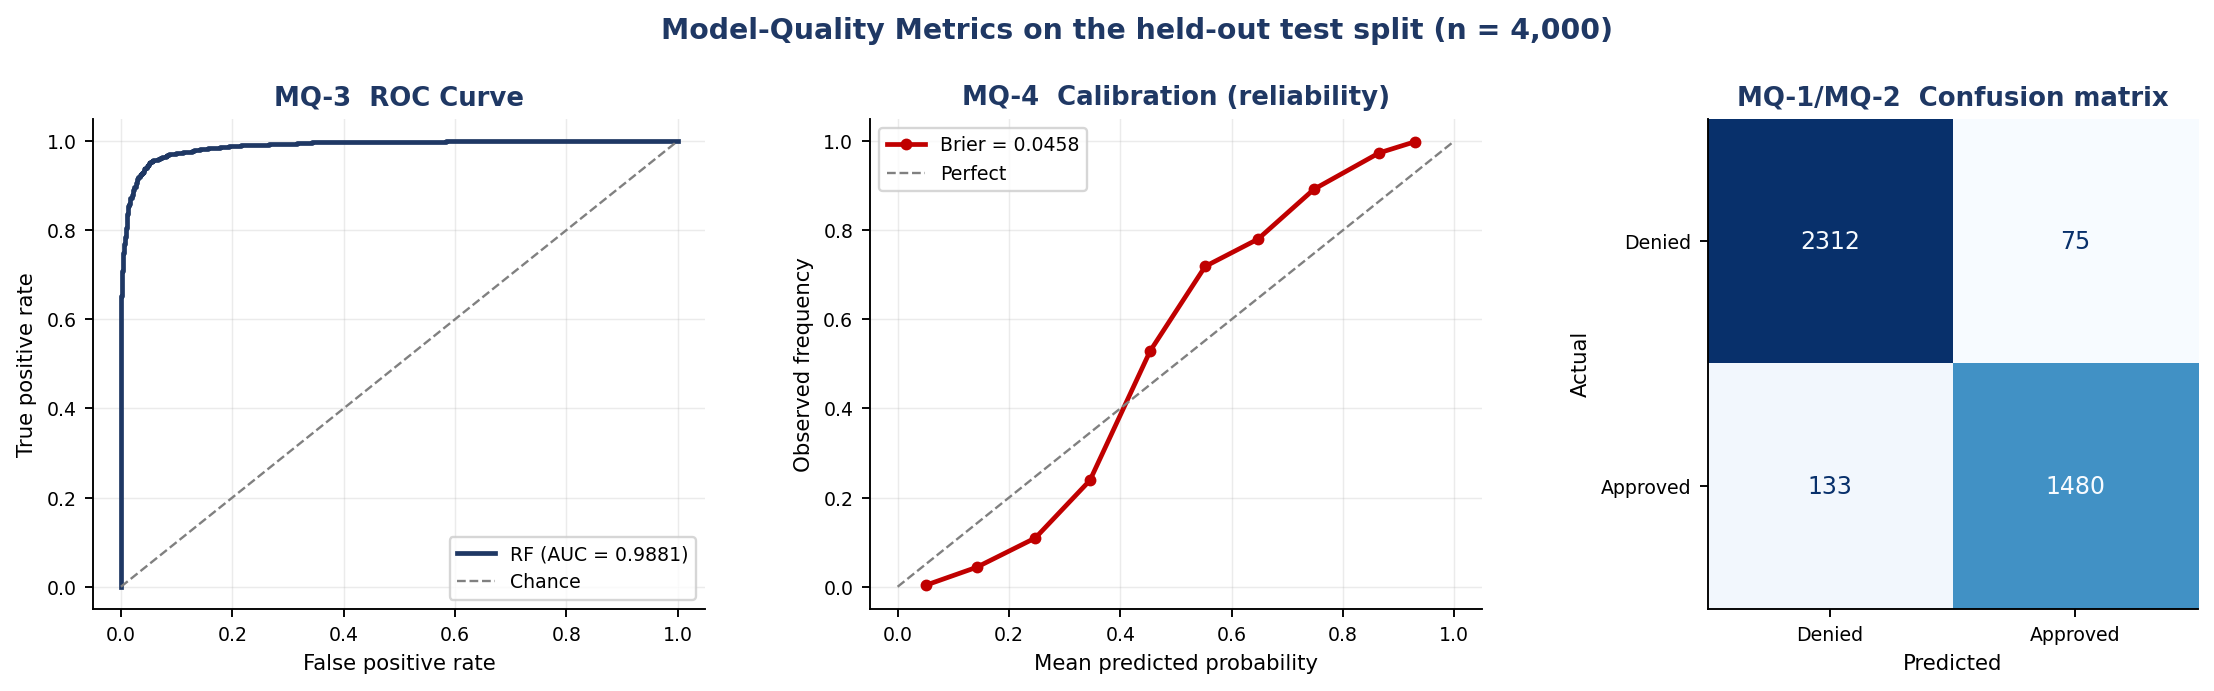

In [27]:
display(Image(str(PROJECT_ROOT / "reports" / "figures" / "model_quality_metrics.png"), width=980))


In [28]:
training = json.loads((PROJECT_ROOT / "reports" / "metrics" / "training_metrics.json").read_text(encoding="utf-8"))
pd.DataFrame(training["algorithm_comparison"]).T[
    ["accuracy", "f1", "precision", "recall", "roc_auc", "brier_score"]
].round(4)


,accuracy,f1,precision,recall,roc_auc,brier_score
logistic_regression,0.903,0.8789,0.8850,0.8729,0.9686,0.0693
random_forest,0.948,0.9343,0.9518,0.9175,0.9881,0.0458


### Limitation: what these numbers do and do not establish

**The dataset is synthetic, and that bounds what the metrics above mean.** The
licensed Kaggle file is not redistributed, so `data/generate_synthetic_data.py`
produces a schema-faithful stand-in whose label is an explicit logistic
expression. **Eight of the 22 model features appear in it** — seven directly,
plus `LoanToIncomeRatio` via the `over_leveraged` threshold — with only
N(0, 0.45) noise.

The forest is therefore recovering a smooth function of its own inputs. That the
logistic baseline also reaches 0.9686 ROC-AUC is the clearest sign of it: both
models approximate a near-logistic generating process rather than discovering
credit risk.

So the honest reading is that **these metrics validate the pipeline, not the
domain**. They show ingestion, feature engineering, training, calibration,
gating and serving are wired together and measured correctly — which is what
Assignment II asks for. They are *not* evidence that this model prices real
credit risk at 94.8% accuracy, and we do not claim it. The licensed dataset
drops in as `data/Loan.csv` with no code change and every figure regenerates.

### 8.2 Data quality — four metrics

In an ML system the data is a dependency exactly as a library is, so it needs
its own measurable contract. DQ-1/DQ-2 gate the training run; DQ-3/DQ-4 monitor
live batches.


In [29]:
report = DataValidator(max_missing_fraction=gates.max_missing_fraction).validate(frame)

pd.DataFrame([
    ("DQ-1", "Schema conformance rate", "= 1.00", report.schema_conformance_rate),
    ("DQ-2", "Missing-value fraction",  f"<= {gates.max_missing_fraction}", report.missing_value_fraction),
    ("DQ-2b", "Worst-column missing",   f"<= {gates.max_missing_fraction}", report.worst_column_missing_fraction),
], columns=["ID", "Metric", "Gate", "Measured"])


{"timestamp": "2026-08-15T16:28:12", "level": "INFO", "logger": "loan_risk.data.validation", "message": "data_quality_gate_passed", "rows": 20000, "schema_conformance_rate": 1.0, "missing_value_fraction": 0.0}


,ID,Metric,Gate,Measured
0,DQ-1,Schema conformance rate,= 1.00,1.0
1,DQ-2,Missing-value fraction,<= 0.02,0.0
2,DQ-2b,Worst-column missing,<= 0.02,0.0


In [30]:
from sklearn.model_selection import train_test_split
from loan_risk.monitoring.drift import DriftMonitor

x_train, x_test = train_test_split(
    features, test_size=settings.model.test_size,
    random_state=settings.model.random_state,
)

# DQ-3 / DQ-4: simulate a recession and confirm the monitor detects it.
recession = x_test.copy()
recession["CreditScore"] = np.clip(recession["CreditScore"] - 85, 300, 850)
recession["DebtToIncomeRatio"] = np.clip(recession["DebtToIncomeRatio"] * 1.6, 0, 10)
recession["CreditCardUtilizationRate"] = np.clip(recession["CreditCardUtilizationRate"] * 1.5, 0, 1)

drift = DriftMonitor(x_train, features=settings.model.features,
                     psi_threshold=gates.max_psi).summary_frame(recession)
print("features flagged SEVERE:", int((drift["severity"] == "SEVERE").sum()), "of", len(drift))
drift.head(6)


{"timestamp": "2026-08-15T16:28:12", "level": "WARNING", "logger": "loan_risk.monitoring.drift", "message": "data_drift_detected", "n_drifted_features": 3, "features": ["CreditScore", "CreditCardUtilizationRate", "DebtToIncomeRatio"]}


features flagged SEVERE: 3 of 22


,feature,psi,ks_statistic,ks_p_value,severity
0,CreditScore,1.8032,0.3774,0.000000,SEVERE
1,DebtToIncomeRatio,0.7680,0.4010,0.000000,SEVERE
2,CreditCardUtilizationRate,0.4335,0.2650,0.000000,SEVERE
3,MonthlyDebtPayments,0.0061,0.0256,0.030009,STABLE
4,LengthOfCreditHistory,0.0043,0.0238,0.053242,STABLE
5,Age,0.0041,0.0210,0.117240,STABLE


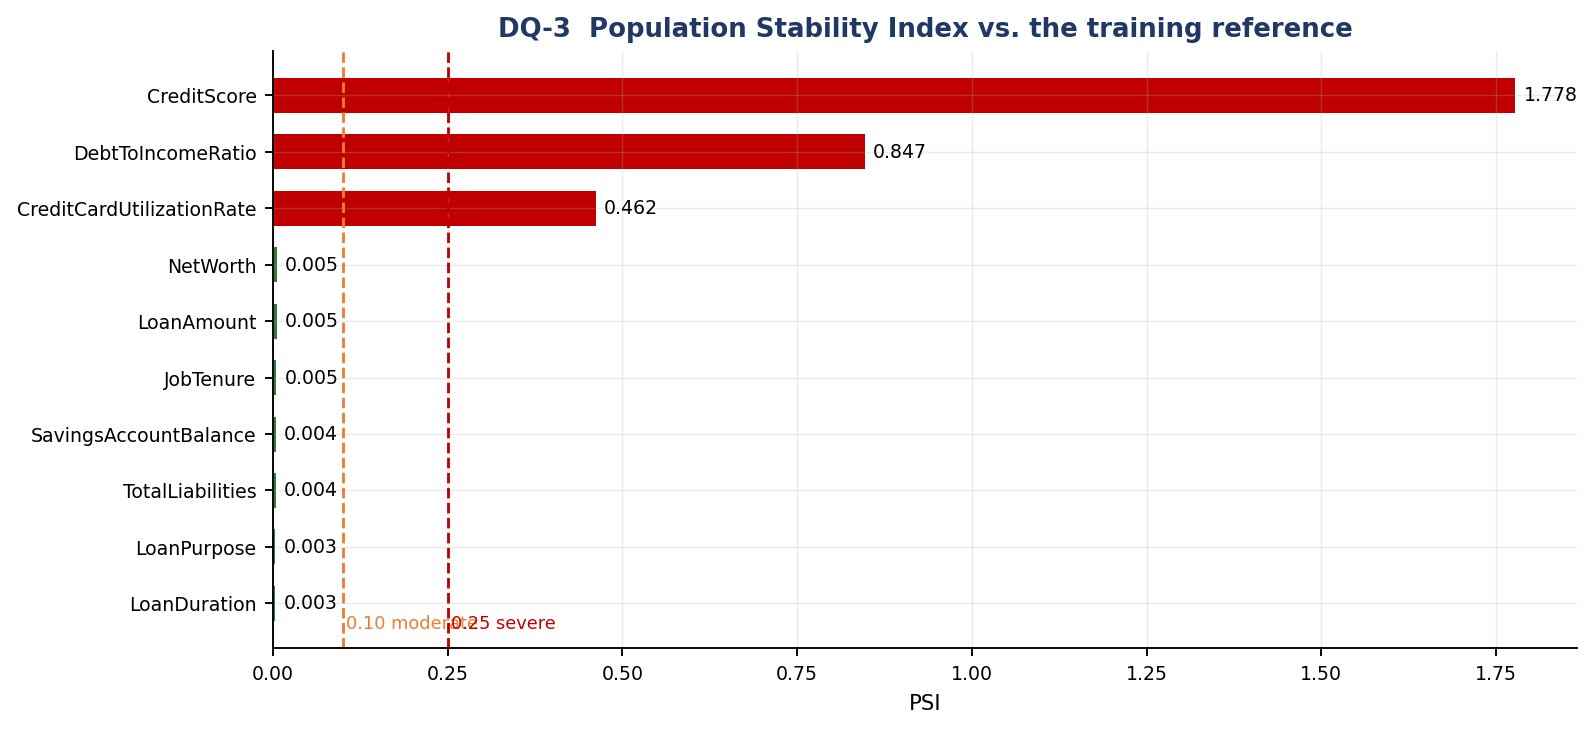

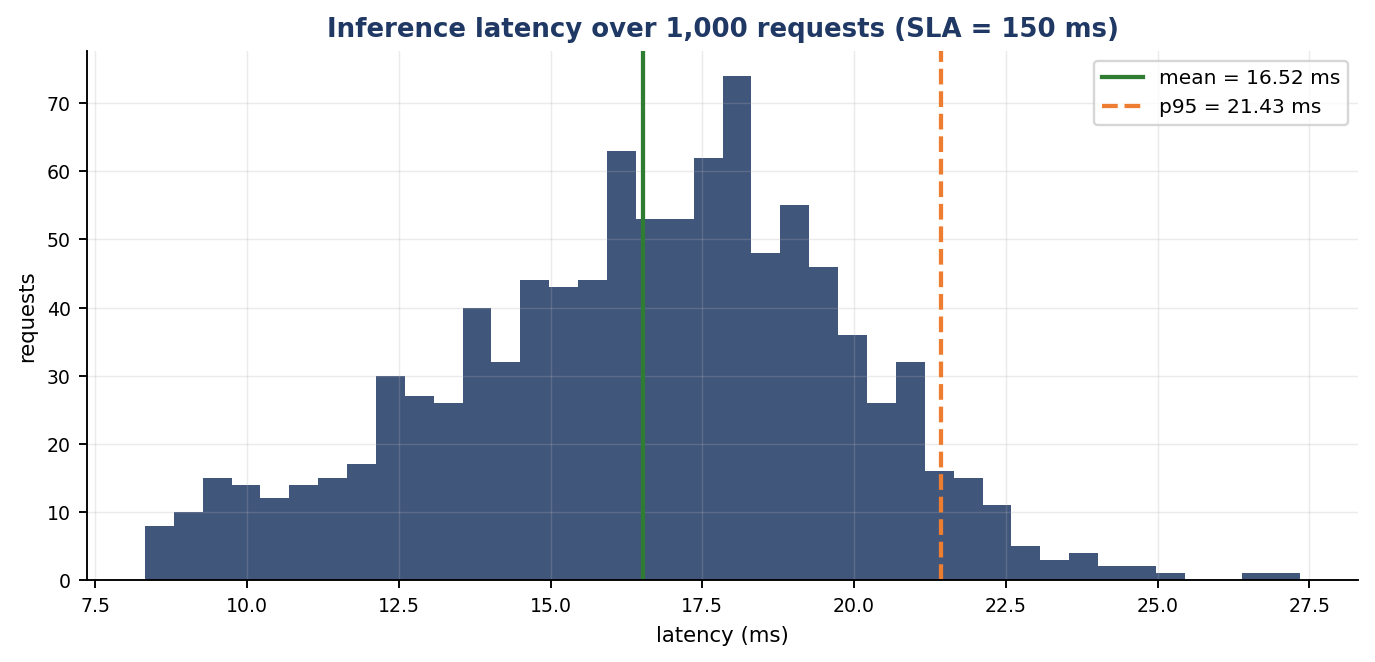

latency: {'mean': 16.516, 'p50': 16.797, 'p95': 21.429, 'p99': 23.656, 'sla': 150.0, 'n_requests': 1000}


In [31]:
display(Image(str(PROJECT_ROOT / "reports" / "figures" / "drift_psi.png"), width=760))
display(Image(str(PROJECT_ROOT / "reports" / "figures" / "latency_distribution.png"), width=680))
print("latency:", qa["latency_ms"])


## 9. Testing in Production, and a Security Consideration

### 9.1 Approach — shadow deployment, then canary

Offline metrics are necessary and not sufficient: a credit model meets a
population it never saw in training, and the label (did the loan default?)
arrives months later. The release path is therefore staged.

| Stage | Traffic | What is compared | Promote when | Roll back when |
|:--|:--|:--|:--|:--|
| **1. Shadow** | 100% mirrored, **0% served** | Candidate scores every live request alongside the incumbent; only the incumbent's answer is returned. Diff score distribution, tier mix, disagreement rate, latency. | ≥ 2 weeks with no unexplained disagreement and p99 within budget | Never — shadow traffic is not served, so a bad candidate cannot harm a customer |
| **2. Canary** | 5% → 25% → 50% → 100% | Live KPIs on the canary slice: approval rate, tier mix, manual-override rate, error rate, p99 latency | Each step held ≥ 48 h with KPIs inside control limits | Automatically on any breach; the previous artifact is one config change away |
| **3. A/B holdout** | Permanent 5% on the incumbent | Realised default rate — the metric that actually matters — measured months later against a like-for-like control | Retained permanently as the reference arm | n/a |

**Why shadow first here specifically.** The outcome label is delayed by months,
so we cannot A/B our way to a fast decision. Shadow mode gives an immediate,
zero-risk read on the one thing observable on day one: whether the candidate's
score distribution and its disagreements with the incumbent are explainable.

The infrastructure already exists in this codebase: `ModelRegistry` makes "which
artifact is loaded" a configuration value, every scoring event is already logged
as JSON carrying `model_version`, and `DriftMonitor` supplies the population
check — so comparing two arms is a log query, not new instrumentation.

### 9.2 Security consideration — the input boundary as an attack surface

The primary threat is **adversarial and malformed input at the scoring
endpoint**: it is reachable from a customer-facing portal, accepts a 20-field
numeric payload, and its output is a lending decision with direct financial
consequence. That invites three abuses — probing to find which field flips a
decision, pushing out-of-distribution values into untested model regions, and
classic injection or resource exhaustion against the service.


In [32]:
pd.DataFrame([
    ("Bounded field constraints (all 20)", "api/schemas.py",
     "Out-of-domain values rejected with 422 before any model code runs"),
    ("extra='forbid'", "api/schemas.py",
     "Unknown keys rejected, not ignored — blocks parameter-pollution probing"),
    ("Strict type coercion", "Pydantic v2",
     "An injection string in a numeric field fails int_parsing; never becomes a query"),
    ("Business-rule filter", "RiskPredictor.validate_business_rules",
     "Semantic gate behind the syntactic one; absurd applications refused with 400"),
    ("Batch size cap (100)", "BatchLoanApplications",
     "Bounds the work one request can demand — basic DoS control"),
    ("Opaque error envelope", "api/app.py exception handlers",
     "Clients get a reason, never a stack trace or module path"),
    ("Full audit log", "logging_utils.py",
     "Every decision recorded with inputs, probability, tier and model_version"),
], columns=["Control", "Where", "Effect"])


,Control,Where,Effect
0,Bounded field constraints (all 20),api/schemas.py,Out-of-domain values rejected with 422 before ...
1,extra='forbid',api/schemas.py,"Unknown keys rejected, not ignored — blocks pa..."
2,Strict type coercion,Pydantic v2,An injection string in a numeric field fails i...
3,Business-rule filter,RiskPredictor.validate_business_rules,Semantic gate behind the syntactic one; absurd...
4,Batch size cap (100),BatchLoanApplications,Bounds the work one request can demand — basic...
5,Opaque error envelope,api/app.py exception handlers,"Clients get a reason, never a stack trace or m..."
6,Full audit log,logging_utils.py,"Every decision recorded with inputs, probabili..."


In [33]:
# The controls, exercised.
adversarial = [
    ("'; DROP TABLE applications;--", "credit_score"),
    ("<script>alert(1)</script>",     "credit_score"),
    ("../../etc/passwd",              "credit_score"),
    (10 ** 15,                        "annual_income"),
]
for value, field in adversarial:
    status = client.post("/v1/predict", json={**APPLICATION, field: value}).status_code
    print(f"{str(value)[:34]:<36} -> HTTP {status}")

rejected = client.post("/v1/predict",
                       json={**APPLICATION, "annual_income": 20000, "loan_amount": 500000})
print("\nbusiness-rule rejection body:", rejected.json(), "  <- no stack trace, no module path")


'; DROP TABLE applications;--        -> HTTP 422


<script>alert(1)</script>            -> HTTP 422
../../etc/passwd                     -> HTTP 422


1000000000000000                     -> HTTP 422
{"timestamp": "2026-08-15T16:28:12", "level": "WARNING", "logger": "loan_risk.models.predictor", "message": "business_rule_rejected", "rule": "max_loan_to_income_multiple", "loan_amount": 500000, "annual_income": 20000}


{"timestamp": "2026-08-15T16:28:12", "level": "WARNING", "logger": "loan_risk.api.app", "message": "request_rejected_by_business_rule", "detail": "Requested amount exceeds 5x annual income."}



business-rule rejection body:

 {'detail': 'Requested amount exceeds 5x annual income.', 'error_type': 'BusinessRuleViolation'}   <- no stack trace, no module path


**What this does not solve.** Field-level validation constrains each value
independently; it cannot detect an application in which every value is
individually plausible but the combination is fabricated. The honest mitigations
sit outside the request path: corroborating declared income and liabilities
against the bureau feed rather than trusting the payload, rate-limiting and
authenticating per client so systematic probing is visible and attributable, and
monitoring the per-caller score distribution for the signature of an
optimisation attack. Model access control — the artifact and the reference
profile are deployment assets, not public ones — belongs in the same list.

---

## Summary

| Task | Deliverable | Evidence |
|:--|:--|:--|
| 1. Refactor (OOP / FP) | `src/loan_risk/` — 11 modules, one responsibility each | Section 1 |
| 2. Research vs production | Assignment I's shipped code (`legacy/`) vs `features/engineering.py` | Section 2 |
| 3. Error handling & logging | Typed exceptions + JSON logging across 3 critical functions | Section 3 |
| 4. Formatting & linting | flake8 59 → 0, black/isort clean, pylint 9.72 → 10.00 | Section 4, `reports/lint/` |
| 5. REST API | FastAPI, versioned paths, 5 status codes, bounded batch | Section 5 |
| 6. Two+ test types | 4 types, 60 tests, 92% line coverage | Section 6 |
| 7. ML tests | Overfit-batch, loss-decreases, shape/range, directional, invariance | Section 7 |
| 8. Metrics | 4 model-quality + 4 data-quality, all gated | Section 8 |
| 9. Production testing & security | Shadow → canary → A/B holdout; input-boundary controls | Section 9 |

**Full report:** `Group_84.pdf` · **Source:** `Group_84/`
